In [20]:
pip install wordcloud

Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple
     -------------------------------------- 153.3/153.3 kB 1.5 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [21]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import numpy as np
from gensim.models import Word2Vec
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE

from sklearn.decomposition import PCA
# 读取分词后的文本数据
from wordcloud import WordCloud
import matplotlib.pyplot as plt




In [ ]:
with open('output.txt', 'r', encoding='utf-8') as f:
    sentences = [line.strip().split() for line in f if line.strip()]

# 训练 Word2Vec 模型
model = Word2Vec(sentences, vector_size=100,
                 window=9, min_count=7,
                 workers=4, sg=0, hs=0,
                 negative=5, epochs=30)

# 定义函数将文档转换为向量
def document_vector(word2vec_model, doc):
    doc = [word for word in doc if word in word2vec_model.wv.key_to_index]
    return np.mean(word2vec_model.wv[doc], axis=0) if doc else np.zeros(word2vec_model.vector_size)

# 计算每个文档的向量表示
doc_vectors = np.array([document_vector(model, doc) for doc in sentences])

# 规范化文档向量
scaler = StandardScaler()
doc_vectors_scaled = scaler.fit_transform(doc_vectors)



# 假设 doc_vectors_scaled 是您已经规范化的文档向量



# 使用 t-SNE 进行降维
tsne = TSNE(n_components=2, random_state=42)
doc_vectors_scaled = tsne.fit_transform(doc_vectors_scaled)

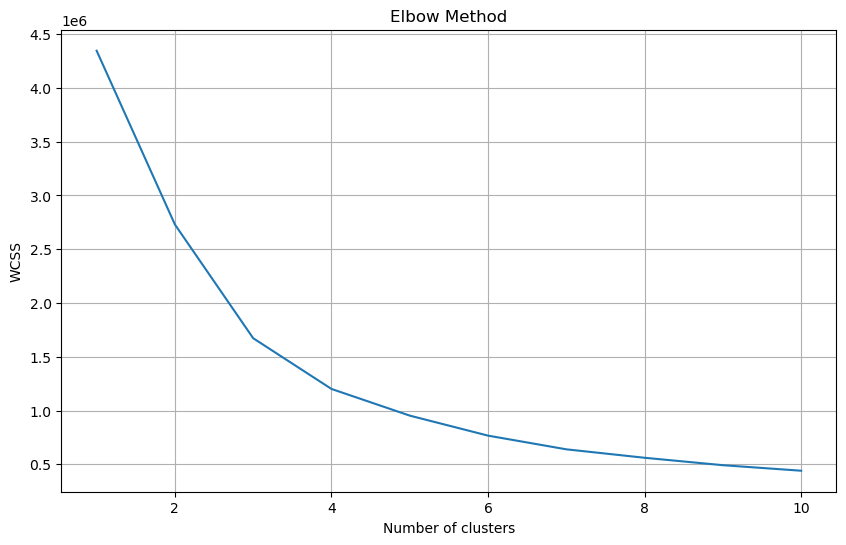

2.3498780131340027
3.3874192237854004
4.389509916305542
5.394024968147278
6.415709763765335
7.411103755235672
8.409888863563538
9.407142698764801
10.404156237840652


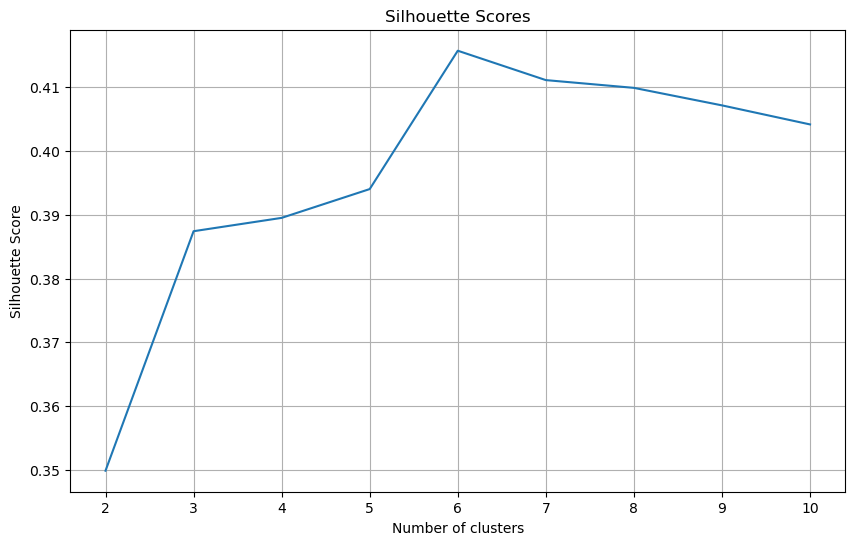

In [6]:

# 肘部法则确定最佳聚类数
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(doc_vectors_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss)
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()


# 轮廓系数分析
silhouette_scores = []
for i in range(2, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    labels = kmeans.fit_predict(doc_vectors_scaled)
    score = silhouette_score(doc_vectors_scaled, labels)
    silhouette_scores.append(score)
    print(i+ score)

plt.figure(figsize=(10, 6))
plt.plot(range(2, 11), silhouette_scores)
plt.title('Silhouette Scores')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.show()

# 0.40575
# 0.40724462

# 0.4137582  k=6 10 6

# 0.4066927 k=6 12 7

Cluster 0:


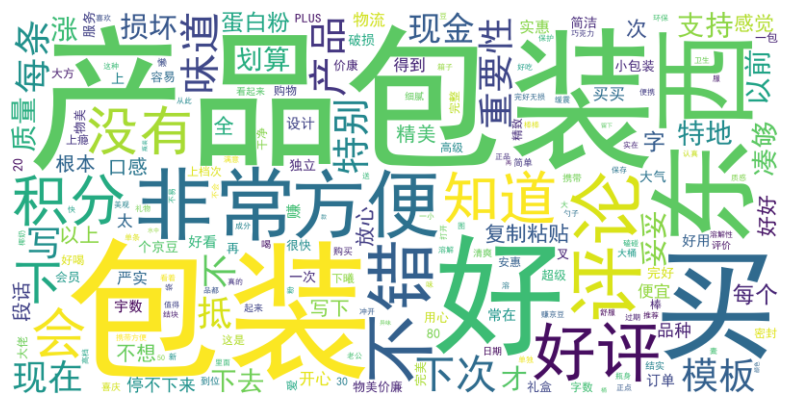

Most common words: [('产品包装', 106), ('包装', 102), ('好', 74), ('买', 63), ('东西', 50), ('非常', 45), ('评论', 40), ('方便', 39), ('不错', 37), ('好评', 36), ('知道', 28), ('积分', 27), ('会', 26), ('没有', 24), ('下', 21)]
Number of samples in cluster: 175

Cluster 1:


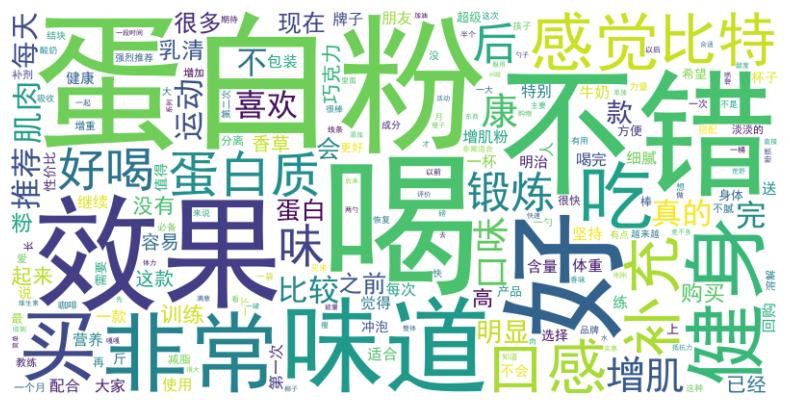

Most common words: [('喝', 141), ('蛋白粉', 140), ('不错', 119), ('好', 106), ('效果', 93), ('味道', 89), ('非常', 81), ('健身', 74), ('买', 66), ('吃', 61), ('感觉', 61), ('口感', 53), ('补充', 53), ('比特', 48), ('蛋白质', 47)]
Number of samples in cluster: 268

Cluster 2:


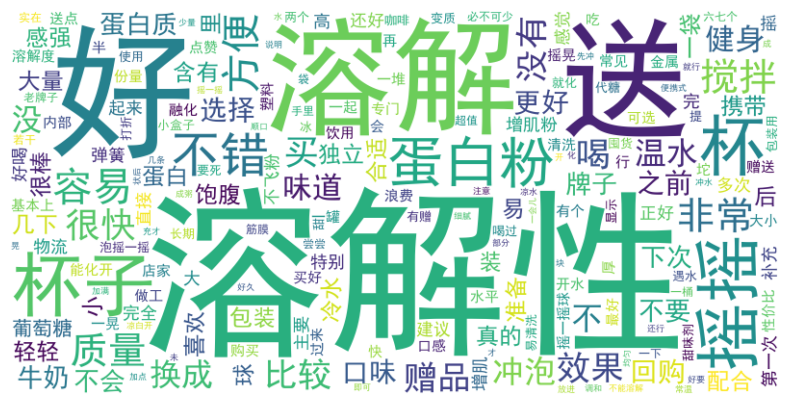

Most common words: [('溶解性', 89), ('好', 55), ('送', 46), ('溶解', 40), ('杯子', 37), ('摇摇', 33), ('杯', 33), ('蛋白粉', 26), ('不错', 20), ('容易', 13), ('方便', 13), ('搅拌', 12), ('非常', 12), ('质量', 12), ('很快', 10)]
Number of samples in cluster: 126

Cluster 3:


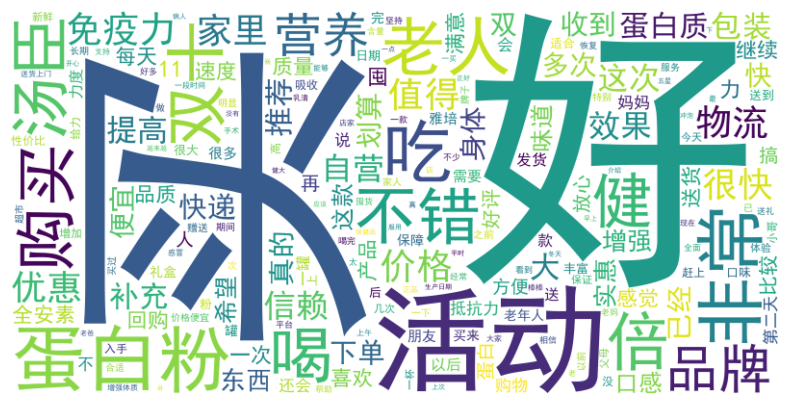

Most common words: [('买', 205), ('好', 167), ('活动', 108), ('蛋白粉', 100), ('吃', 96), ('非常', 95), ('老人', 80), ('倍', 77), ('不错', 75), ('购买', 74), ('双十', 73), ('喝', 69), ('汤臣', 68), ('健', 67), ('品牌', 64)]
Number of samples in cluster: 288

Cluster assignments: [1 0 0 ... 2 2 2]


In [23]:
# kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
# labels = kmeans.fit_predict(doc_vectors_scaled)
optimal_k=4
kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42)
clusters = kmeans.fit_predict(doc_vectors_scaled)

for i in set(clusters):
    print(f"Cluster {i}:")

    # 提取该聚类的所有样本
    cluster_samples = [sentences[j] for j in range(len(sentences)) if labels[j] == i]

    # 计算词频
    word_counts = Counter(word for sample in cluster_samples for word in sample)
#     wordcloud = WordCloud(font_path='simhei.ttf', width=mask_width, height=mask_height,
#                       background_color='white', mask=ellipse_mask)
    wordcloud = WordCloud(font_path='simhei.ttf', width=800, height=400, background_color='white').generate_from_frequencies(dict(word_counts))

    # 显示词云图
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.show()
    # 打印最常见的词
    print("Most common words:", word_counts.most_common(15))
    print("Number of samples in cluster:", len(cluster_samples))
    print()

# 打印聚类结果
print("Cluster assignments:", clusters)

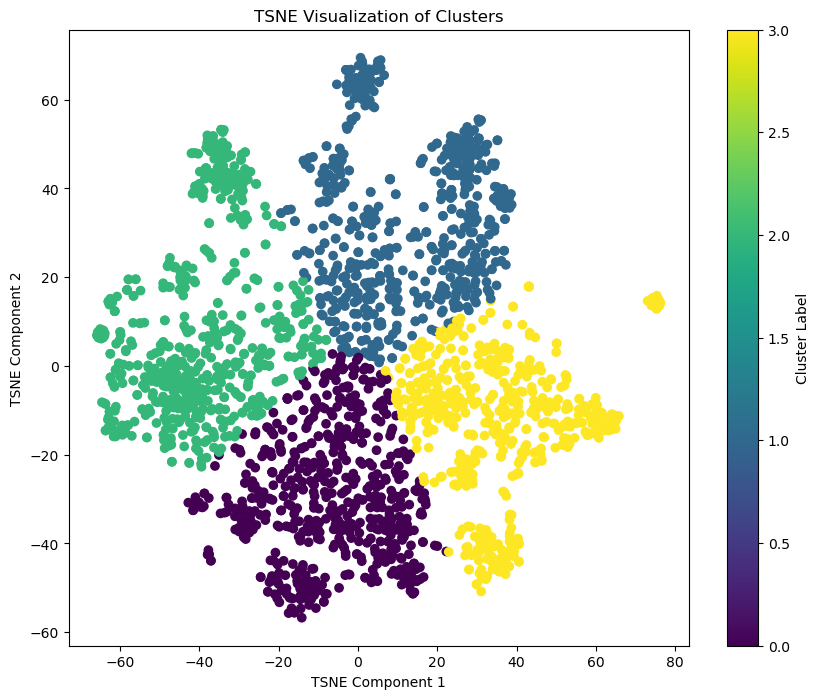

In [24]:
# doc_vectors_pca = pca.fit_transform(doc_vectors_scaled)  # doc_vectors_scaled 是您之前规范化的文档向量

doc_vectors_tsne = doc_vectors_scaled

plt.figure(figsize=(10, 8))
plt.scatter(doc_vectors_tsne[:, 0], doc_vectors_tsne[:, 1], c=clusters, cmap='viridis')  # clusters 是 K-Means 聚类的结果
plt.xlabel('TSNE Component 1')
plt.ylabel('TSNE Component 2')
plt.title('TSNE Visualization of Clusters')
plt.colorbar(label='Cluster Label')
plt.show()

In [25]:
from collections import Counter

# 假设 sentences 是原始的分词文本数据
# 假设 clusters 是 K-Means 聚类的结果

cluster_word_lists = {}
# 1. 收集每个聚类中的单词
for cluster_id in set(clusters):
    cluster_word_lists[cluster_id] = [word for i, sentence in enumerate(sentences) if clusters[i] == cluster_id for word in sentence]
cluster_word_frequencies = {}

# 2. 计算词频和百分比占比
for cluster_id, words in cluster_word_lists.items():
    word_counts = Counter(words)
    total_count = sum(word_counts.values())
    cluster_word_frequencies[cluster_id] = {word: count / total_count for word, count in word_counts.items()}
    
#    输出结果
for cluster_id, word_freqs in cluster_word_frequencies.items():
    print(f"Cluster {cluster_id}:")
    for word, freq in word_freqs.items():
        print(f"{word}: {freq:.2%}")
    print()


Cluster 0:
汤臣: 0.54%
倍: 0.61%
健: 0.52%
牌子: 0.21%
放心: 0.24%
安心: 0.04%
蛋白粉: 1.70%
送给: 0.02%
老年人: 0.17%
做过: 0.01%
手术: 0.19%
人: 0.24%
食用: 0.08%
营养: 1.55%
提高: 0.33%
身体: 0.53%
免疫力: 0.55%
冲泡: 0.07%
方便: 0.25%
还会: 0.18%
继续: 0.35%
回购: 0.46%
物流: 0.61%
快: 0.39%
植物: 0.06%
固体: 0.01%
饮料: 0.02%
非常: 1.39%
好: 2.46%
丰富: 0.18%
老人: 1.12%
孩子: 0.07%
适合: 0.34%
家里: 0.67%
喝: 1.31%
赶上: 0.14%
双十: 0.86%
一做: 0.01%
活动: 1.14%
性价比: 0.34%
超高: 0.02%
喝汤: 0.03%
臣: 0.03%
搞: 0.21%
再: 0.31%
囤点: 0.02%
包装: 0.51%
精美: 0.05%
送礼: 0.09%
自用: 0.02%
均: 0.01%
自营: 0.41%
购买: 1.10%
相信: 0.09%
正品: 0.09%
发货: 0.15%
很快: 0.55%
第二天: 0.18%
收到: 0.33%
推荐: 0.58%
选汤臣: 0.01%
老: 0.07%
品牌: 0.77%
平台: 0.07%
店: 0.05%
囗: 0.01%
碑: 0.01%
信誉: 0.02%
确保: 0.02%
选: 0.05%
产品: 0.48%
质量: 0.31%
家人: 0.13%
增加: 0.12%
抵抗力: 0.28%
一段时间: 0.12%
后: 0.24%
效果: 0.78%
好会: 0.01%
选购: 0.01%
不错: 1.34%
至少: 0.02%
家里人: 0.08%
喜欢: 0.44%
基本: 0.02%
每年: 0.04%
会: 0.39%
帮: 0.04%
买: 3.01%
买错: 0.01%
只: 0.04%
一罐: 0.18%
没有: 0.18%
价格: 0.81%
优惠: 0.54%
总体: 0.04%
一款: 0.18%
值得: 0.71%
蛋白质: 0.49%
补充剂: 0.0

In [26]:
import numpy as np

# 假设 doc_vectors 是原始的 Word2Vec 文档向量
# 假设 clusters 是 K-Means 聚类的结果

# 初始化一个字典来保存每个聚类的平均向量
cluster_average_vectors = {}

# 计算每个聚类的平均向量
for cluster_id in set(clusters):
    cluster_docs = [doc_vectors[i] for i in range(len(doc_vectors)) if clusters[i] == cluster_id]
    cluster_average_vectors[cluster_id] = np.mean(cluster_docs, axis=0)

# 找出与每个聚类的平均向量最接近的单词
for cluster_id, avg_vector in cluster_average_vectors.items():
    # 使用 Word2Vec 模型的相似度函数
    similar_words = model.wv.similar_by_vector(avg_vector, topn=5)
    print(f"Cluster {cluster_id}:")
    for word, similarity in similar_words:
        print(f"{word}: {similarity:.2f}")
    print()


Cluster 0:
几罐: 0.91
老爸: 0.82
几桶: 0.80
好几: 0.80
药店: 0.78

Cluster 1:
丝滑: 0.87
算是: 0.86
甜味: 0.86
味道: 0.85
很甜: 0.85

Cluster 2:
公司: 0.90
商品质量: 0.89
运送: 0.87
仔细: 0.86
服务态度: 0.84

Cluster 3:
国人: 0.83
碳水化合物: 0.81
大豆: 0.81
尤其: 0.81
增长: 0.80

